# **- The Name 👤: `Raghad Mohamed Abd El-Alim Malek Zarad`**
# **- The Student ID  : `EYOUTH-31109170100123`**
# **- The Project Name 📝 : `City Library After-School Program`**

**- The Project Description :**

* A city library runs an `After-School Program` for students. The program keeps track of two things: which students are members, and which books each member has borrowed.

* Every summer, the library also hosts an event called the `Reading Kickoff`. At this event, a student can borrow a book without using their membership card. Because there's no card involved, these borrowing records aren't stored with the rest — they're logged separately, on the library's website.

*  The program coordinator is now writing an `End-of-Summer Reading Report`, and needs the data to be accurate and complete before that report can be written.

**- 🎒 My Role in the Project :**

`I am the library's data assistant. I'm the one responsible for handing over the data in a shape someone else can actually work with.`

Now we will start solving the tasks.

- We have 3 tasks to do in the project :
* Task 1 : Data Gathering & combination `(Combined Data)`
* Task 2 : Data Integrity `(Cleaned Data)`
* Task 3 : Data Fairness & Version Control

# **Introduction to the system**

In [1394]:
# the introduction
print("Welcome to the City Library After-School Program!")
print("This program keeps track of two things: which students are members, and which books each member has borrowed.")
print("Every summer, the library  hosts an event called the Reading Kickoff.")
print("At this event, a student can borrow a book without using their membership card.")
print("Because there's no card involved, these borrowing records aren't stored with the rest — they're logged separately, on the library's website.")
print("The program coordinator is now writing an End-of-Summer Reading Report, and needs the data to be accurate and complete before that report can be written.")
print()
print("Loading the system.........")

Welcome to the City Library After-School Program!
This program keeps track of two things: which students are members, and which books each member has borrowed.
Every summer, the library  hosts an event called the Reading Kickoff.
At this event, a student can borrow a book without using their membership card.
Because there's no card involved, these borrowing records aren't stored with the rest — they're logged separately, on the library's website.
The program coordinator is now writing an End-of-Summer Reading Report, and needs the data to be accurate and complete before that report can be written.

Loading the system.........


# **Checking the Cloud Machine**

In [1395]:
# getting the info about the cloud machine and the python version
print("The Cloud Machine and the python version used : ")
import sys , platform
print(f"Python Version : {sys.version}")
print(f"Cloud Machine : {platform.node()}")

The Cloud Machine and the python version used : 
Python Version : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Cloud Machine : f1a134089e0a


# **Importing all the required libraries in python**

In [1396]:
print("Importing the required libraries in python ......")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sql
from bs4 import BeautifulSoup
import requests
import json
import time

# importing the warnings library to prevent any errors from the library
import warnings
warnings.filterwarnings("ignore")
time.sleep(1.5)
print("The Libraries are loaded successfully :)")

Importing the required libraries in python ......
The Libraries are loaded successfully :)


### we will import the 3 sources of data to work on (db , json , html) to explore them  , answer the questions , and merge the 3 sources into 1 CSV File .

# **Task 1 : Data Collection and Combination**

In [1397]:
print("Loading the 3 sources of data............")
time.sleep(1)
print("The data is loaded successfully......")

Loading the 3 sources of data............
The data is loaded successfully......


### The SQL database

In [1398]:
# the database connection
conn = sql.connect("/content/level3_final_project_library.db")

# function to ease working with SQL queries
def run(query):
    return pd.read_sql_query(query, conn)

# getting the tables from the database
members = run("SELECT * FROM members")
books = run("SELECT * FROM books")
checkouts = run("SELECT * FROM checkouts")


Exploring the Members Table

In [1399]:
print("The tables in the database : ")
time.sleep(1)

The tables in the database : 


In [1400]:
print(f"The Table :\n {members}")
print()
print(f"The Dataset Shape : {members.shape}")
print()
print(f"The Dataset Info :\n {members.info()}")
print()
print(f"The statistical Description :\n {members.describe(include=np.number)}")
print()
print(f"The columns in the table : \n {members.columns.to_list()}")

The Table :
     member_id first_name last_name  grade neighborhood membership_status  \
0        1001      Salma   Ibrahim    8.0        Maadi            Active   
1        1002      Fares     Saleh    9.0        Maadi            Active   
2        1003     Bassel    Hegazy    6.0        Maadi            Active   
3        1004      Fares     Wahba    7.0        Maadi          inactive   
4        1005    Youssef     Halim    9.0        Maadi            Active   
..        ...        ...       ...    ...          ...               ...   
75       1076       Dina     Wahba    7.0       Shubra            Active   
76       1077       Lina    Rashad    6.0       Shubra            Active   
77       1078     Habiba     Osman    7.0       Shubra          INACTIVE   
78       1079       Rana     Osman    8.0       Shubra            Active   
79       1080     Bassel     Wahba    9.0       Shubra            Active   

     join_date  
0   2023-04-05  
1         None  
2   2025-04-23  
3   20

Exploring the Books Table

In [1401]:
print(f"The Table :\n {books}")
print()
print(f"The Dataset Shape : {books.shape}")
print()
print(f"The Dataset Info :\n {books.info()}")
print()
print(f"The statistical Description :\n {books.describe(include=np.number)}")
print()
print(f"The columns in the table : \n {books.columns.to_list()}")

The Table :
     book_id                    title          author
0       501          The Silver Kite   Amina Darwish
1       502           Desert Compass   Amina Darwish
2       503        The Lantern Maker    Adel Roushdy
3       504      Rooftop Astronomers    Adel Roushdy
4       505      Letters to the Nile       Aya Hafez
5       506      The Paper Boat Club       Aya Hafez
6       507    Fossils and Fireflies     Dalia Serry
7       508    The Quiet Observatory     Dalia Serry
8       509      Marbles and Mirrors     Diaa Sultan
9       510    The Missing Metronome     Diaa Sultan
10      511     Winter in Alexandria    Farida Anwar
11      512   The Cartographer's Cat    Farida Anwar
12      513   Circuits for Beginners    Galal Mounir
13      514    The Robot in Row Nine    Galal Mounir
14      515       Songs of the Oasis      Hoda Bakry
15      516  The Beekeeper's Almanac      Hoda Bakry
16      517  Shadows on the Corniche     Hani Nagati
17      518     The Ninth Lightho

Exploring the Checkouts Table

In [1402]:
print(f"The Table :\n {checkouts}")
print()
print(f"The Dataset Shape : {checkouts.shape}")
print()
print(f"The Dataset Info :\n {checkouts.info()}")
print()
print(f"The statistical Description :\n {checkouts.describe(include=np.number)}")
print()
print(f"The columns in the table : \n {checkouts.columns.to_list()}")

The Table :
      checkout_id  member_id  book_id checkout_date return_date
0           9263       1047      517    2024-10-21  2024-11-07
1           9340       1072      513    2025-08-24  2025-09-01
2           9231       1053      523    2024-02-04  2024-02-16
3           9129       1032      513    2025-06-21  2025-06-29
4           9370       1079      511    2025-11-11  2025-12-03
..           ...        ...      ...           ...         ...
386         9232       1044      513    2025-05-26  2025-06-11
387         9084       1008      511    2024-06-27  2024-07-22
388         9116       1024      519    2025-01-10  2025-02-09
389         9352       1076      501    2025-02-02        None
390         9246       1044      529    2025-06-25  2025-07-04

[391 rows x 5 columns]

The Dataset Shape : (391, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         ---------

### The json file

In [1403]:
print("The data in the json file : ")
time.sleep(1.3)

The data in the json file : 


In [1404]:
json_df = pd.read_json("/content/level3_final_project_book_catalog.json")
print(f"The Table :\n {json_df}")
print()
print(f"The Dataset Shape : {json_df.shape}")
print()
print(f"The Dataset Info :\n {json_df.info()}")
print()
print(f"The statistical Description :\n {json_df.describe(include=np.number)}")
print()
print(f"The columns in the table : \n {json_df.columns.to_list()}")

The Table :
     book_id            genre  pages  publication_year            publisher
0       501        Adventure    128            2017.0           Nile Press
1       502        Adventure    109            2018.0          Delta House
2       503       Historical    259               NaN           Nile Press
3       504          Science    319            2009.0  Cairo Young Readers
4       505       Historical    216            2024.0          Oasis Books
5       506       Friendship    183               NaN           Nile Press
6       507          Science    160            2024.0           Nile Press
7       508          Science    306            2011.0          Oasis Books
8       509          Mystery    221            2011.0           Nile Press
9       510          Mystery    134            2013.0  Cairo Young Readers
10      511       Historical    117            2016.0           Nile Press
11      512        Adventure    238            2022.0          Delta House
12      513 

### The html file (website)

In [1405]:
print("The HTML table : ")
time.sleep(1.5)

The HTML table : 


In [1406]:
# getting the data from the website
html_tables = pd.read_html("/content/level3_final_project_event_signups.html")
the_table = html_tables[0]

#  renaming the columns of the html tables to help in the merging process
the_table = the_table.rename(columns={"Member ID" : "member_id"})
the_table = the_table.rename(columns={"Book ID" : "book_id" })
the_table = the_table.rename(columns={"Checkout Date" : "checkout_date"})

# simple inspection process
print(f"The Table :\n {the_table}")
print()
print(f"The Dataset Shape : {the_table.shape}")
print()
print(f"The Dataset Info :\n {the_table.info()}")
print()
print(f"The statistical Description :\n {the_table.describe(include=np.number)}")
print()
print(f"The columns in the table : \n {the_table.columns.to_list()}")
print()



The Table :
     member_id  book_id checkout_date
0        1026      522    2025-07-11
1        1049      520    2025-07-11
2        1062      525    2025-07-05
3        1065      520    2025-07-07
4        1104      515    2025-07-07
5        1009      503    2025-07-09
6        1063      522    2025-07-07
7        1022      511    2025-07-12
8        1029      523    2025-07-09
9        1201      509    2025-07-10
10       1005      513    2025-07-10
11       1104      526    2025-07-05
12       1058      518    2025-07-08
13       1002      521    2025-07-08
14       1150      530    2025-07-10
15       1041      504    2025-07-05
16       1055      526    2025-07-11
17       1061      513    2025-07-06
18       1012      509    2025-07-11
19       1007      510    2025-07-07
20       1073      530    2025-07-07
21       1003      501    2025-07-08
22       1017      507    2025-07-11
23       1061      504    2025-07-06
24       1201      523    2025-07-08
25       1041      512   

Now , We will make a copy of the original datasets to return to them if needed

In [1407]:
print("Making a copy of the original data to return to it when needed.........")
# the database copy
members_copy = members.copy()
books_copy = books.copy()
checkouts_copy = checkouts.copy()

# the json copy
json_df_copy = json_df.copy()

# the html copy
the_table_copy = the_table.copy()
time.sleep(1.5)
print("The coping process is completed successfull :)")

Making a copy of the original data to return to it when needed.........
The coping process is completed successfull :)


## **Answering the 5 Question :**

In [1408]:
print("Asking the questions to the SQL database and getting the answers.....")
time.sleep(1)
print("asking......")
time.sleep(0.5)
print("getting the answer.....")
time.sleep(0.5)
print("Processing.......")
time.sleep(1.5)
print("the process was completed successfully :) ")

Asking the questions to the SQL database and getting the answers.....
asking......
getting the answer.....
Processing.......
the process was completed successfully :) 


Question 1 : How much is each member borrowing ?

In [1409]:
# Question 1: How much is each member borrowing?
print("Question 1: How much is each member borrowing?")
time.sleep(0.5)
print("The answer : ")
print()
Q1 = """SELECT members.member_id,
                  members.first_name,
                  members.last_name,
                  COUNT(checkouts.checkout_id) AS the_number_of_borrowings
FROM checkouts
JOIN members ON checkouts.member_id = members.member_id
GROUP BY members.first_name, members.last_name
"""

run(Q1)

Question 1: How much is each member borrowing?
The answer : 



,member_id,first_name,last_name,the_number_of_borrowings
0,1017,Adam,Badr,2
1,1065,Adam,Fahmy,17
2,1053,Adam,Shafik,5
3,1057,Ahmed,Fahmy,10
4,1049,Ahmed,Gamal,1
...,...,...,...,...
57,1005,Youssef,Halim,3
58,1024,Youssef,Hegazy,17
59,1061,Ziad,Fahmy,8
60,1013,Ziad,Fouad,2


Question 2 : Which books match a choosen author pattern ?

In [1410]:
# Question 2 : Which books match a choosen author pattern ?
# I chose the authors with the beginning of M

print("Question 2 : Which books match a choosen author pattern ?")
time.sleep(0.5)
print("I chose the authors with the beginning of M")
time.sleep(1)
print("The answer : ")
print()
Q2 = """SELECT author, title
From books
WHERE author Like 'M%'
"""

run(Q2)

Question 2 : Which books match a choosen author pattern ?
I chose the authors with the beginning of M
The answer : 



,author,title
0,Mahmoud Rafei,Storms and Sailboats
1,Mahmoud Rafei,The Clockwork Orchard
2,Mona Kholoussy,Notes from the Delta
3,Mona Kholoussy,The Glass Beehive


Question 3 : What are the most popular books ?

In [1411]:
# Question 3 : What are the most popular books ?
print("Question 3 : What are the most popular books ?")
time.sleep(0.5)
print("The answer : ")
print()
Q3 = """SELECT bookS.title,
               COUNT(checkouts.checkout_id) AS the_number_of_borrowings
FROM checkouts
JOIN books ON checkouts.book_id = books.book_id
GROUP BY books.title
ORDER BY the_number_of_borrowings DESC LIMIT 5
"""

run(Q3)

Question 3 : What are the most popular books ?
The answer : 



,title,the_number_of_borrowings
0,The Silver Kite,57
1,Fossils and Fireflies,55
2,Circuits for Beginners,46
3,Kites Over Cairo,38
4,Storms and Sailboats,25


Question 4 : What are the most effective active readers ?

In [1412]:
# Question 4 : What are the most effective active readers ?
print("Question 4 : What are the most effective active readers ?")
time.sleep(0.5)
print("The answer : ")
print()
Q4 = """SELECT members.member_id,
               members.first_name,
               members.last_name,
               COUNT(checkouts.checkout_id) AS the_number_of_borrowings
FROM checkouts
JOIN members ON checkouts.member_id = members.member_id
GROUP BY members.first_name, members.last_name
ORDER BY the_number_of_borrowings DESC LIMIT 10
"""

run(Q4)

Question 4 : What are the most effective active readers ?
The answer : 



,member_id,first_name,last_name,the_number_of_borrowings
0,1034,Aya,Wahba,25
1,1044,Sherif,Saleh,21
2,1008,Ziad,Saleh,19
3,1027,Mostafa,Fouad,18
4,1010,Nour,Nabil,18
5,1065,Adam,Fahmy,17
6,1018,Ahmed,Shafik,17
7,1024,Youssef,Hegazy,17
8,1030,Reem,Osman,16
9,1047,Sara,Rashad,16


 Question 5 : What does a neghboorhood's activity look like futher back in time ? (Maadi)

In [1413]:
# Re-read members to get the number of unique values for each neighborhood and choose 1 neighbourhood
members = run("SELECT * FROM members")
neighborhoods_names = members["neighborhood"].value_counts()
print(f"The available neighborhoods count : \n {neighborhoods_names}")

The available neighborhoods count : 
 neighborhood
Maadi         22
Nasr City     19
Heliopolis    18
Zamalek       14
Shubra         6
Nasr  City     1
Name: count, dtype: int64


I will clean the cities in the neighborhood column in members table inside the database to get all the cities

In [1414]:
# cleaning the column of the neighbourhood by giving them the right format
members["neighborhood"] = members["neighborhood"].str.lower().str.title().str.strip()

print("Unique neighborhoods AFTER cleaning:")
print(members["neighborhood"].unique())

members.to_sql("members", conn, if_exists="replace", index=False)
print("\nDatabase 'members' table updated with cleaned neighbourhoods")
print(members["neighborhood"].unique())

members.to_sql("members", conn, if_exists="replace", index=False)
print("\nDatabase 'members' table updated with cleaned neighborhoods.")

print('Value counts AFTER cleaning (from DataFrame):')
print(members["neighborhood"].value_counts())

Unique neighborhoods AFTER cleaning:
['Maadi' 'Nasr City' 'Nasr  City' 'Heliopolis' 'Zamalek' 'Shubra']

Database 'members' table updated with cleaned neighbourhoods
['Maadi' 'Nasr City' 'Nasr  City' 'Heliopolis' 'Zamalek' 'Shubra']

Database 'members' table updated with cleaned neighborhoods.
Value counts AFTER cleaning (from DataFrame):
neighborhood
Maadi         22
Nasr City     19
Heliopolis    18
Zamalek       14
Shubra         6
Nasr  City     1
Name: count, dtype: int64


In [1415]:
print("Question 5 : What does a neghboorhood's activity look like futher back in time ? (Maadi)")
time.sleep(1)
print("The answer : ")
print()
Q5 = """SELECT members.member_id,
               members.first_name,
               members.last_name,
               members.neighborhood,
               checkouts.checkout_date
FROM members
LEFT JOIN checkouts ON members.member_id = checkouts.member_id
WHERE members.neighborhood = 'Maadi' AND checkouts.checkout_date IS NOT NULL
ORDER BY checkouts.checkout_date DESC LIMIT 10 OFFSET 10
"""

run(Q5)

# The JOIN method has many types
# defalt --> INNER
# and the INNER JOIN couldn't join what I neeeded , so I used the LEFT JOIN

Question 5 : What does a neghboorhood's activity look like futher back in time ? (Maadi)
The answer : 



,member_id,first_name,last_name,neighborhood,checkout_date
0,1011,Menna,Halim,Maadi,2025-10-02
1,1003,Bassel,Hegazy,Maadi,2025-09-17
2,1010,Nour,Nabil,Maadi,2025-09-08
3,1003,Bassel,Hegazy,Maadi,2025-09-04
4,1010,Nour,Nabil,Maadi,2025-09-02
5,1010,Nour,Nabil,Maadi,2025-08-27
6,1017,Adam,Badr,Maadi,2025-08-25
7,1008,Ziad,Saleh,Maadi,2025-08-23
8,1003,Bassel,Hegazy,Maadi,2025-08-21
9,1018,Ahmed,Shafik,Maadi,2025-08-19


# Merging Process :

## Merging the members table and the checkouts table by python.

In [1416]:
# Merging the members table and the checkouts table by python.

print("merging the two tables (members , checkouts)......")
time.sleep(1)
print("wait a little bit.......")
time.sleep(1.5)
merged_members_checkouts_sql = members.merge(checkouts, on="member_id", how="outer")
print("the process was completed successfully :)")
print(f"The Table :\n {merged_members_checkouts_sql}")

merging the two tables (members , checkouts)......
wait a little bit.......
the process was completed successfully :)
The Table :
      member_id first_name last_name  grade neighborhood membership_status  \
0         1001      Salma   Ibrahim    8.0        Maadi            Active   
1         1002      Fares     Saleh    9.0        Maadi            Active   
2         1002      Fares     Saleh    9.0        Maadi            Active   
3         1003     Bassel    Hegazy    6.0        Maadi            Active   
4         1003     Bassel    Hegazy    6.0        Maadi            Active   
..         ...        ...       ...    ...          ...               ...   
404       1079       Rana     Osman    8.0       Shubra            Active   
405       1079       Rana     Osman    8.0       Shubra            Active   
406       1079       Rana     Osman    8.0       Shubra            Active   
407       1080     Bassel     Wahba    9.0       Shubra            Active   
408       1080     Bas

calculating the total borrowings

In [1417]:
print("Calculating each member's total book count...")
# Calculate the total book count for each member
member_book_counts = merged_members_checkouts_sql.groupby('member_id').size().reset_index(name='total_books_checked_out')

print(member_book_counts)
print("Each member's total book count has been calculated and displayed.")

Calculating each member's total book count...
    member_id  total_books_checked_out
0        1001                        1
1        1002                        2
2        1003                        9
3        1004                        1
4        1005                        3
..        ...                      ...
75       1076                        7
76       1077                        6
77       1078                        1
78       1079                       10
79       1080                        2

[80 rows x 2 columns]
Each member's total book count has been calculated and displayed.


Merging the merged tables with the total borrowings

In [1418]:
print("Integrating total book counts with merged member and checkout data...")

# Merge the calculated total book counts with the main merged DataFrame
final_sql_merged_data = merged_members_checkouts_sql.merge(
    member_book_counts,
    on='member_id',
    how='left'
)
time.sleep(1)
print("The process was completed successfully :)")
print("The result : ")
# Display the first few rows of the updated DataFrame to show the new 'total_books_checked_out' column
print(final_sql_merged_data.head())
print("Member details, checkout details, and total book count are now combined in 'final_merged_data'.")

Integrating total book counts with merged member and checkout data...
The process was completed successfully :)
The result : 
   member_id first_name last_name  grade neighborhood membership_status  \
0       1001      Salma   Ibrahim    8.0        Maadi            Active   
1       1002      Fares     Saleh    9.0        Maadi            Active   
2       1002      Fares     Saleh    9.0        Maadi            Active   
3       1003     Bassel    Hegazy    6.0        Maadi            Active   
4       1003     Bassel    Hegazy    6.0        Maadi            Active   

    join_date  checkout_id  book_id checkout_date return_date  \
0  2023-04-05       9025.0    525.0    2024-10-24  2024-11-07   
1        None       9013.0    501.0    2024-02-16  2024-02-29   
2        None       9095.0    507.0    2024-06-25  2024-07-07   
3  2025-04-23       9051.0    513.0    2025-07-22  2025-08-18   
4  2025-04-23       9068.0    501.0    2025-11-14  2025-12-03   

   total_books_checked_out  
0  

## Merging the merged dataset `(sql)` with the `json file` and the `html table`.

first : the json file

In [1419]:
sql_json_merged = final_sql_merged_data.merge(json_df , on = "book_id" , how = "left")
# I used how = "left" to get all the book details and get only the book details of the available members and checkouts only
print(f"The Table :\n {sql_json_merged}")
print()
# simple inspection process
print(f"The 1st 5 rows inside the merged table : \n {sql_json_merged.head()}")
print()
print(f"The Dataset Shape : {sql_json_merged.shape}")
print()
print(f"The Dataset Info :\n {sql_json_merged.info()}")
print()
print(f"The statistical Description :\n {sql_json_merged.describe(include=np.number)}")
print()
print(f"The columns inside the merged table : \n {sql_json_merged.columns.to_list()}")

The Table :
      member_id first_name last_name  grade neighborhood membership_status  \
0         1001      Salma   Ibrahim    8.0        Maadi            Active   
1         1002      Fares     Saleh    9.0        Maadi            Active   
2         1002      Fares     Saleh    9.0        Maadi            Active   
3         1003     Bassel    Hegazy    6.0        Maadi            Active   
4         1003     Bassel    Hegazy    6.0        Maadi            Active   
..         ...        ...       ...    ...          ...               ...   
404       1079       Rana     Osman    8.0       Shubra            Active   
405       1079       Rana     Osman    8.0       Shubra            Active   
406       1079       Rana     Osman    8.0       Shubra            Active   
407       1080     Bassel     Wahba    9.0       Shubra            Active   
408       1080     Bassel     Wahba    9.0       Shubra            Active   

      join_date  checkout_id  book_id checkout_date return_dat

Before merging between 2 different tables with the purpose of `html table` and the `merged SQL JSON dataset`, we must give the necessary columns the right type to prevent any outliers, missing values or errors during the merging process.

In [1420]:
# changing the types of essencial columns temporarily for the merging process; then I will give them the right type

# the merged sql json dataset
sql_json_merged["member_id"] = sql_json_merged["member_id"].astype(pd.Int64Dtype())
# Use nullable integer type for book_id to get it to the integer type without any proplems or errors during the merging process because of the missing values (nan).
sql_json_merged["book_id"] = sql_json_merged["book_id"].astype(pd.Int64Dtype())
sql_json_merged["checkout_date"] = pd.to_datetime(sql_json_merged["checkout_date"] , format = "mixed")

# the html table
the_table["member_id"] = the_table["member_id"].astype(int)
the_table["book_id"] = the_table["book_id"].astype(int)
the_table["checkout_date"] = pd.to_datetime(the_table["checkout_date"] , format = "mixed")

second : the html table

In [1421]:
# the final merging process :)

the_complete_merged_dataset = sql_json_merged.merge(the_table , on = ["member_id" , "book_id" , "checkout_date"] , how = "outer")
# I used how = "outer" instead of keep = "left" to keep the columns and all the members and prevent any accidental deletion during the merging process or any missing membermembers.
print(f"The Table :\n {the_complete_merged_dataset}")

The Table :
      member_id first_name last_name  grade neighborhood membership_status  \
0         1001      Salma   Ibrahim    8.0        Maadi            Active   
1         1002      Fares     Saleh    9.0        Maadi            Active   
2         1002      Fares     Saleh    9.0        Maadi            Active   
3         1002        NaN       NaN    NaN          NaN               NaN   
4         1003     Bassel    Hegazy    6.0        Maadi            Active   
..         ...        ...       ...    ...          ...               ...   
430       1104        NaN       NaN    NaN          NaN               NaN   
431       1104        NaN       NaN    NaN          NaN               NaN   
432       1150        NaN       NaN    NaN          NaN               NaN   
433       1201        NaN       NaN    NaN          NaN               NaN   
434       1201        NaN       NaN    NaN          NaN               NaN   

      join_date  checkout_id  book_id checkout_date return_dat

Updating the total borrowings to remove the possible NaNs in this column

In [1422]:
print("Calculating each member's total book count...")
# Calculate the total book count for each member
total_counts = the_complete_merged_dataset.groupby('member_id').size().reset_index(name='total_books_checked_out')

print(member_book_counts)
print("Each member's total book count has been calculated and displayed.")

Calculating each member's total book count...
    member_id  total_books_checked_out
0        1001                        1
1        1002                        2
2        1003                        9
3        1004                        1
4        1005                        3
..        ...                      ...
75       1076                        7
76       1077                        6
77       1078                        1
78       1079                       10
79       1080                        2

[80 rows x 2 columns]
Each member's total book count has been calculated and displayed.


merging the total borrowings with the combined dataset

In [1423]:
print("Integrating updated total book counts with the combined dataset...")

# Remove the old 'total_books_checked_out' column which was based only on SQL data
if 'total_books_checked_out' in the_complete_merged_dataset.columns:
    the_complete_merged_dataset = the_complete_merged_dataset.drop(columns=['total_books_checked_out'])

# Merge the newly calculated total_counts (which includes all checkouts) into the_complete_merged_dataset
final_combined_data_with_count = the_complete_merged_dataset.merge(
    total_counts,
    on='member_id',
    how='left'
)
time.sleep(1)
print("The process was completed successfully :)")
print("The result : ")
# Display the first few rows of the updated DataFrame to show the new 'total_books_checked_out' column
print(final_combined_data_with_count)
print("Member details, checkout details, and updated total book count are now combined in 'final_combined_data_with_count'.")

Integrating updated total book counts with the combined dataset...
The process was completed successfully :)
The result : 
     member_id first_name last_name  grade neighborhood membership_status  \
0         1001      Salma   Ibrahim    8.0        Maadi            Active   
1         1002      Fares     Saleh    9.0        Maadi            Active   
2         1002      Fares     Saleh    9.0        Maadi            Active   
3         1002        NaN       NaN    NaN          NaN               NaN   
4         1003     Bassel    Hegazy    6.0        Maadi            Active   
..         ...        ...       ...    ...          ...               ...   
430       1104        NaN       NaN    NaN          NaN               NaN   
431       1104        NaN       NaN    NaN          NaN               NaN   
432       1150        NaN       NaN    NaN          NaN               NaN   
433       1201        NaN       NaN    NaN          NaN               NaN   
434       1201        NaN     

## Simple inspection for the combined dataset before turning it to a CSV file

In [1424]:
print("Small inspectation for the combined dataset.........")
time.sleep(0.5)
print("Inspecting..........")
time.sleep(0.5)
print("The inspection process was completed successfully :)")
print()
print(f"The Dataset : \n {final_combined_data_with_count}")
print()
print(f"The Dataset shape : {final_combined_data_with_count.shape}")
print()
print(f"The Dataset info : \n {final_combined_data_with_count.info()}")
print()
print(f"The statistical Description : \n {final_combined_data_with_count.describe(include=np.number)}")
print()
print(f"The columns inside the merged table : \n {final_combined_data_with_count.columns.to_list()}")

Small inspectation for the combined dataset.........
Inspecting..........
The inspection process was completed successfully :)

The Dataset : 
      member_id first_name last_name  grade neighborhood membership_status  \
0         1001      Salma   Ibrahim    8.0        Maadi            Active   
1         1002      Fares     Saleh    9.0        Maadi            Active   
2         1002      Fares     Saleh    9.0        Maadi            Active   
3         1002        NaN       NaN    NaN          NaN               NaN   
4         1003     Bassel    Hegazy    6.0        Maadi            Active   
..         ...        ...       ...    ...          ...               ...   
430       1104        NaN       NaN    NaN          NaN               NaN   
431       1104        NaN       NaN    NaN          NaN               NaN   
432       1150        NaN       NaN    NaN          NaN               NaN   
433       1201        NaN       NaN    NaN          NaN               NaN   
434      

## Turning the dataset into a CSV file that can be downloaded

In [1425]:
# The converting process
print("Converting to a csv file......")
time.sleep(1)
final_combined_data_with_count.to_csv("31109170100123_Library_task1_combined_data.csv" , index = False)
print("The converting process was completed successfully :)")
time.sleep(0.5)
print("We successfully finished Task 1")

Converting to a csv file......
The converting process was completed successfully :)
We successfully finished Task 1


# **Before proceeding to task 2, I will outline the steps I completed in task 1 to ensure transparency in my process.**

## Initially, I imported the necessary Python libraries. I then loaded three data sources: `an SQL database, an HTML website, and a JSON file.` Using the `sqlite3 library`, I addressed the five questions by executing database queries. Subsequently, I merged the members and checkouts tables, followed by integration with the `JSON dataset` and, finally, the `HTML table` dataset.

## Additionally, I obtained the `HTML table` from the website through `WEB SCRAPING` and read it using the `pd.read_html()` function.

# **Now , let's talk about APIs ans web scraping**

# **What is the difference between the API and web scraping?**
To begin with, Application Programming Interfaces `(APIs)` represent 2 fundamentally different approaches to data acquisition (data collection from websites). APIs provide a structured and efficient mechanism for data transfer, enabling direct access to specified data fields and collecting them in an organised, machine-readable format `(JSON files)` with great speed. This ensures high reliability, but it is limited, and you can't collect all the data `(limited data access by the API provider)`. You must also respect the website's terms and policies `(robot.txt)` and avoid making too many requests, so the website server doesn't stop.


On the other hand, web scraping involves extracting data yourself programmatically `(parsing the entire content of the web pages, especially HTML tables)`. While web scraping offers broader access to any publicly visible data, it is less efficient, prone to data quality issues due to inconsistent formatting, and highly sensitive to changes in website structure. For the library case, I used web scraping because the website for the reading kick-off event doesn't have an API, so I used the pandas function `pd.read_html()`.


# **Now, let's get to task 2 :)**

# **Task 2 : Data Integrity**

In [1426]:
# imported the Combined CSV file
print("Getting the Merged dataset.......")
df_clean = pd.read_csv("/content/31109170100123_Library_task1_combined_data.csv")# reading the csv file and getting the data from it
time.sleep(1) # sleep for 1 second
print("The process was completed successfully :)") # success message

Getting the Merged dataset.......
The process was completed successfully :)


# **Inspecting the CSV file dataset**

In [1427]:
print("Inspecting the dataset.........")
time.sleep(0.5)
print("Loading the CSV file........")
time.sleep(0.5)
print("The CSV was loaded successfully :)")
time.sleep(0.5)
print("Continue the inspectation process.......")
time.sleep(1)
print("The process was completed successfully :)")
print("The Dataset : ")
print()
print(f"The Dataset : \n {df_clean}") # the dataset
print()
print(f"The 1st 5 rows in the dataset --> \n {df_clean.head(n=5)}") # the 1st 5 rows
print()
print(f"The last 5 rows in the dataset --> \n {df_clean.tail(n=5)}") # the last 5 rows in the dataset
print()
print(f"The dataset shape --> {df_clean.shape}") # the shape of the dataset(nrows , ncols)
print()
print(f"The dataset size --> {df_clean.size}") # the size of the dataset
print()
print(f"The dataset info --> \n {df_clean.info()}") # the general information of the dataset
print()
print(f"The statistical description of the dataset --> \n {df_clean.describe(include=np.number)}") # the statistical analysis of the numerical columns of the dataset
print()
print(f"The columns inside the dataset --> \n {df_clean.columns.to_list()}") # putting the columns' names of the dataset in a list
print()
print(f"The number of duplicated rows --> {df_clean.duplicated().sum()}") # the number of duplicated rows in the dataset
print()
duplicated = df_clean[df_clean.duplicated()]
print(f"The duplicated rows --> \n {duplicated}") # the duplicated rows
print(f"The number of missing values in the dataset for each column --> \n {df_clean.isnull().sum()}") # the number of missing values in each column
print()
print(f"The types of the columns in the dataset --> \n {df_clean.dtypes}") # the dtype of each column


Inspecting the dataset.........
Loading the CSV file........
The CSV was loaded successfully :)
Continue the inspectation process.......
The process was completed successfully :)
The Dataset : 

The Dataset : 
      member_id first_name last_name  grade neighborhood membership_status  \
0         1001      Salma   Ibrahim    8.0        Maadi            Active   
1         1002      Fares     Saleh    9.0        Maadi            Active   
2         1002      Fares     Saleh    9.0        Maadi            Active   
3         1002        NaN       NaN    NaN          NaN               NaN   
4         1003     Bassel    Hegazy    6.0        Maadi            Active   
..         ...        ...       ...    ...          ...               ...   
430       1104        NaN       NaN    NaN          NaN               NaN   
431       1104        NaN       NaN    NaN          NaN               NaN   
432       1150        NaN       NaN    NaN          NaN               NaN   
433       1201     

### **When we inspected the dataset, we found out that there are many problems in the combined dataset :**
* Duplicated Rows: 8
* Missing Values: many missing values, especially in the return date column
* Inconsistent Formating : in the neighboorhood , member status , dates (return date , checkout date) and others like IDs that are floats and they must be strings.

# **"Now , we will start the Cleaning process for the dataset."**

### **before the cleaning process , we must make a copy of the dataset**

In [1428]:
print("Making a copy of the original data to return to it when needed.........")
# The df copy
df_copy = df_clean.copy() # .copy() makes a copy of the dataset in a new variable..........
time.sleep(0.5)
print("The Coping process was completed successfully :)")

Making a copy of the original data to return to it when needed.........
The Coping process was completed successfully :)


## **The duplicated rows**

In [1429]:
print("Getting the duplicated rows.........")
time.sleep(0.8)
the_duplicated_rows = df_clean[df_clean.duplicated()]
print(f"The duplicated rows : \n {the_duplicated_rows}") # the duplicated rows
time.sleep(0.5)
print()
# the number of duplicated rows before getting rid of them
the_duplicated_before_clean = df_clean.duplicated().sum()
print(f"The number of duplicated rows before getting rid of them : {the_duplicated_before_clean}")
df_clean = df_clean.drop_duplicates(keep = "first")
time.sleep(0.5) # delay for half a second
print("Cleaning the dataset from the duplicated rows.........")
time.sleep(1) # delay for a second
print("The process was completed successfully :)")
time.sleep(0.3)
print(f"The number of duplicated rows after getting rid of them : {df_clean.duplicated().sum()}")
time.sleep(0.3)
print("Rechecking.......")
time.sleep(0.5) # delay for half a second
the_duplicated_rows_recheck = df_clean[df_clean.duplicated()]
# checking if there were any duplicated rows after cleaning
print(f"The duplicated rows : {the_duplicated_rows_recheck}")


Getting the duplicated rows.........
The duplicated rows : 
      member_id first_name last_name  grade neighborhood membership_status  \
101       1019    Mostafa     Wahba    6.0        Maadi          Inactive   
128       1024    Youssef    Hegazy    8.0    Nasr City          inactive   
202       1034        Aya     Wahba    9.0    Nasr City            Active   
210       1034        Aya     Wahba    9.0    Nasr City            Active   
247       1044     Sherif     Saleh    7.0   Heliopolis            active   
291       1054      Retaj     Fahmy    6.0   Heliopolis          Inactive   
343       1065       Adam     Fahmy    6.0      Zamalek            Active   
348       1065       Adam     Fahmy    6.0      Zamalek            Active   

      join_date  checkout_id  book_id checkout_date return_date       genre  \
101  2024-07-20       9052.0    501.0    2024-06-20  2024-06-29   Adventure   
128  2024-01-04       9194.0    513.0    2024-09-17  2024-10-09     Science   
202  202

## **Inconsistent Formating**

In [1430]:
#===========================================================Inconsistent Formating===============================================================
# the types of each column
print("Getting the dtype of each column........")
time.sleep(1) # delay for a second
print(f"The type of each column before the dealing process: \n {df_clean.dtypes}")
time.sleep(0.5) # delay for half a second
print()
print("Dealing with the inconsistent formating.......")
time.sleep(2) # delay for 2 seconds
# first : turning the member_id column to string dtype
df_clean["member_id"] = df_clean["member_id"].astype(pd.Int64Dtype())
df_clean["member_id"] = df_clean["member_id"].astype(str).replace("<NA>" , np.nan) # turning the nan after it became a string to a np.nan that could be filled with fillna()
# second : turning the first_name , last_name from object dtype to string dtype
df_clean["first_name"] = df_clean["first_name"].astype(str).str.lower().str.strip().str.title()
df_clean["first_name"] = df_clean["first_name"].replace("Nan" , np.nan) # turning the nan after it became a string to a np.nan that could be filled with fillna()
df_clean["last_name"] = df_clean["last_name"].astype(str).str.lower().str.strip().str.title()
df_clean["last_name"] = df_clean["last_name"].replace("Nan" , np.nan) # turning the nan after it became a string to a np.nan that could be filled with fillna()
# third : turning the grade from float dtype to string dtype
df_clean["grade"] = pd.to_numeric(df_clean["grade"], errors="coerce").astype(pd.Int64Dtype())
# we used pd.INT64type to turn the type of the column to int dtype in the presence of the NaNs
# I turned it to an int first to prevent the decimal point from appearing in the string
df_clean["grade"] = df_clean["grade"].astype(str).replace("<NA>" , np.nan) # turning the nan after it became a string to a np.nan that could be filled with fillna()

# fourth : turning the neighborhood column from object dtype to str dtype and fixing multiple pictures for the 1-word.
df_clean["neighborhood"] = df_clean["neighborhood"].astype(str).str.lower().str.title().str.strip().str.replace(r"\s+", " ", regex=True) # fixing multiple pictures for the 1-word
# regex = True parameter to tell the code to treat the string as an expression, not as a piece of text
df_clean["neighborhood"] = df_clean["neighborhood"].replace("Nan" , np.nan) # turning the nan after it became a string to a np.nan that could be filled with fillna()
# fifth : turning the membership_status column from object dtype to str dtype and fixing multiple pictures for the 1-word
df_clean["membership_status"] = df_clean["membership_status"].astype(str).str.lower().str.title().str.strip().str.replace(r"\s+" , " " , regex=True)
# \s+ means multiple spaces, like in the meighborhood column present in Nasr   City
#So we use it to symbolise many whitespaces and use it in the replace method to replace it with 1 white space

df_clean["membership_status"] = df_clean["membership_status"].replace("Nan" , np.nan)
# sixth : turning the join_date , checkout_date , return_date from object dtype to datetime dtype in multiple formats
df_clean["join_date"] = pd.to_datetime(df_clean["join_date"] , format = "mixed" , errors = "coerce")
df_clean["checkout_date"] = pd.to_datetime(df_clean["checkout_date"] , format = "mixed" , errors = "coerce" )
df_clean["return_date"] = pd.to_datetime(df_clean["return_date"] , format = "mixed", errors="coerce")
#errors='coerce' is a parameter that forces data conversion without errors.
#It automatically replaces any invalid or unconvertible values with missing value markers like NaN or NaT instead of crashing the code.
# seventh : turning the checkout_id and book_id columns from float dtype to str dtype
df_clean["checkout_id"] = pd.to_numeric(df_clean["checkout_id"] , errors = "coerce").astype(pd.Int64Dtype())
df_clean["checkout_id"] = df_clean["checkout_id"].astype(str).replace("<NA>" , np.nan) # turning the nan after it became a string to a np.nan that could be filled with fillna()
df_clean["book_id"] = pd.to_numeric(df_clean["book_id"] , errors = "coerce").astype(pd.Int64Dtype())
df_clean["book_id"] = df_clean["book_id"].astype(str).replace("<NA>" , np.nan) # turning the nan after it became a string to a np.nan that could be filled with fillna()
# eighth : turning genre column from the object dtype to the str dtype
df_clean["genre"] = df_clean["genre"].astype(str).str.lower().str.title().str.strip()
df_clean["genre"] = df_clean["genre"].replace("Nan" , np.nan) # turning the nan after it became a string to a np.nan that could be filled with fillna()
# ninth : turning the pages and publication_year columns from float dtype to int dtype
df_clean["pages"] = pd.to_numeric(df_clean["pages"] , errors = "coerce").astype(pd.Int64Dtype())
df_clean["pages"] = pd.to_numeric(df_clean["pages"] , errors = "coerce").astype(pd.Int64Dtype())
df_clean["publication_year"] = pd.to_numeric(df_clean["publication_year"] , errors = "coerce").astype(pd.Int64Dtype())
# last but not least , converting the publisher column from object dtype to str dtype
df_clean["publisher"] = df_clean["publisher"].astype(str).str.lower().str.title().str.strip()
df_clean["publisher"] = df_clean["publisher"].replace("Nan" , np.nan) # turning the nan after it became a string to a np.nan that could be filled with fillna()

# checking the types of each column after the dealing process
print("The dealing process was completed successfully :)")
time.sleep(0.5)
print("Getting the result of the dealing process...............")
time.sleep(0.8)
print(f"The result of the dealing process : \n {df_clean.dtypes}")

Getting the dtype of each column........
The type of each column before the dealing process: 
 member_id                    int64
first_name                  object
last_name                   object
grade                      float64
neighborhood                object
membership_status           object
join_date                   object
checkout_id                float64
book_id                    float64
checkout_date               object
return_date                 object
genre                       object
pages                      float64
publication_year           float64
publisher                   object
total_books_checked_out      int64
dtype: object

Dealing with the inconsistent formating.......
The dealing process was completed successfully :)
Getting the result of the dealing process...............
The result of the dealing process : 
 member_id                          object
first_name                         object
last_name                          object
grade       

## **Missing Values**

In [1431]:
# ==============================================================the missing values==============================================================
print("Getting the number of missing values in the dataset........")
time.sleep(0.5) # delay for half a second
the_missing_values = df_clean.isnull().sum() # getting the number of the missing values in each column before cleaning
print(f"The number of missing values in the dataset for each column : \n {the_missing_values}")
time.sleep(0.3)
print(f"The total number of missing values in the dataset before cleaning : {df_clean.isnull().sum().sum()}") # The total number of missing values in the dataset before cleaning
print()
# getting the percentage of the missing values for each column to determine if we need to delete a column or not
the_missing_values_percentage = ((the_missing_values / df_clean.shape[0])*100).round(2) # the percentage of the missing values in each column
print(f"The percentage of the missing values for each column : \n {the_missing_values_percentage.astype(str)}%")
print()
print("Filling the missing values...........")
# dealing with the missing values by each column
# 1st : The neighborhood column
df_clean["neighborhood"] = df_clean["neighborhood"].fillna(df_clean["neighborhood"].mode()[0]) # I filled the missing values of the neighborhood column with the mode
# 2nd : The grade column
df_clean["grade"] = df_clean["grade"].fillna(df_clean["grade"].mode()[0])  # I filled the missing values of the grade column with the mode
# 3rd : The membership_status column
df_clean["membership_status"] = df_clean["membership_status"].fillna(df_clean["membership_status"].mode()[0]) # I filled the missing values of the membership_status column with the mode
# 4th : The pages and publication_year columns
df_clean["pages"] = df_clean["pages"].fillna(round(df_clean["pages"].mean())) # I filled the missing values of the pages column with the mean because there are no outliers
df_clean["publication_year"] = df_clean["publication_year"].fillna(df_clean["publication_year"].median()) # I filled the missing values of the publication_year column with the median
# 5th: The publisher column
df_clean["publisher"] = df_clean["publisher"].fillna("Unknown") # I filled the missing values of the publisher column with 'Unknown' to be realistic and not fill them wrongly
# 6th : The join_date column
df_clean["join_date"] = df_clean["join_date"].fillna(df_clean["join_date"].mode()[0])  # I filled the missing values of the join_date column with the mode
# 7th : The return_date column
df_clean["return_date"] = df_clean["return_date"].fillna("Not Returned")# I filled the missing values of the return_date column with 'Not Returned' to be realistic and not fill them wrongly
# 8th : The first_name and the last_name columns+
df_clean["first_name"] = df_clean["first_name"].fillna("Not Available")
df_clean["last_name"] = df_clean["last_name"].fillna("Not Available")
# I filled the missing values of the first_name and last_name columns with 'Not Available' to be realistic and not fill them wrongly and to do the analysis directly without any errors or warnings, and we can reach these students and ask them for all their missing info
# 9th : The genre Column
# Calculate the mode of 'genre' for each 'book_id' to fill missing values.
# This operation will only fill NaN values and will not delete any rows.
# We use .dropna(subset=['genre']) before grouping to ensure that only non-missing genres are used for mode calculation.
# dropna(subset = ["genre"])
genre_mode_by_book = df_clean.dropna(subset=["genre"]).groupby("book_id")["genre"].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
# In Python, lambda x creates a concise, one-line anonymous function
# It takes x as an input argument, evaluates a single expression and automatically returns the result.
# Fill missing genre values using the calculated mode based on book_id.
df_clean["genre"] = df_clean["genre"].fillna(df_clean["book_id"].map(genre_mode_by_book))

# Fill any remaining NaNs in 'genre' with the overall mode of the 'genre' column
# This ensures all genre NaNs are handled, especially for book_ids that had no non-missing genres.
overall_genre_mode = df_clean["genre"].mode()[0] if not df_clean["genre"].mode().empty else "Unknown"
df_clean["genre"] = df_clean["genre"].fillna(overall_genre_mode)

# 10th : The checkout_date
df_clean["checkout_date"] = df_clean["checkout_date"].fillna(df_clean["checkout_date"].mode()[0])  # I filled the missing values of the checkout_date column with the mode
#11th : The checkout_id
df_clean["checkout_id"] = df_clean["checkout_id"].fillna("Missing")
#12th : The book_id
df_clean["book_id"] = df_clean["book_id"].fillna("Missing")
# I filled the missing values of the checkout_id and book_id  columns with 'Missing' to be realistic and not fill them wrongly and to do the analysis directly without any errors or warnings, and we can reach these students and ask them for all their missing info
# 13th : the member_id
df_clean["member_id"] = df_clean["member_id"].fillna("Lost ID") # I filled the missing values of the member_id column with 'Lost ID' to be realistic and not fill them wrongly

print("Filling the missing values.......")
time.sleep(0.5) # delay
print("Wait a little bit.......")
time.sleep(0.5) # delay
print("The process was completed successfully :)")
time.sleep(0.3) # delay
print("Calculating the number of missing values after the cleaning process........")
time.sleep(0.7) # delay
print()
the_missing_values_after_clean = df_clean.isnull().sum() # calculating the missing values in each column after the cleaning process
print(f"The number of missing values in the dataset for each column : \n {the_missing_values_after_clean}")
print(f"The total number of missing values in the dataset after cleaning : {df_clean.isnull().sum().sum()}")# calculating the total number of missing values in the dataset after the cleaning process

Getting the number of missing values in the dataset........
The number of missing values in the dataset for each column : 
 member_id                    0
first_name                  26
last_name                   26
grade                       64
neighborhood                26
membership_status           26
join_date                   32
checkout_id                 44
book_id                     18
checkout_date               18
return_date                109
genre                       44
pages                       44
publication_year            76
publisher                   44
total_books_checked_out      0
dtype: int64
The total number of missing values in the dataset before cleaning : 597

The percentage of the missing values for each column : 
 member_id                    0.0
first_name                  6.09
last_name                   6.09
grade                      14.99
neighborhood                6.09
membership_status           6.09
join_date                   7.49
checko

# **Verify if all the members in the cleaned combined data is in  `members` table...........**

In [1432]:
print("Checking for members ids in the cleaned combined dataset if they are present in the members table.........")
time.sleep(1) # delay
# member ids in the cleaned combined dataset
members_ids_in_cleaned_dataset = df_clean["member_id"].unique()
# members ids in the members table
members_ids_in_members = members["member_id"].astype(str).unique()

# if conditional
if all(member_id in members_ids_in_members for member_id in members_ids_in_cleaned_dataset):
    print("All members in the cleaned combined dataset are in the members table.")
else:
    print("Not all members in the cleaned combined dataset are in the members table.")
    missing_members = set(members_ids_in_cleaned_dataset) - set(members_ids_in_members)
    print(f"The following members are not in the members table: {missing_members}")
    # the rows of the missing members in the members table
    print("Getting the rows of the missing members........")
    time.sleep(1) # delay
    missing_ids_rows = df_clean[df_clean["member_id"].isin(missing_members)]
    print(f"The rows of the missing members in the members table : \n {missing_ids_rows}")


Checking for members ids in the cleaned combined dataset if they are present in the members table.........
Not all members in the cleaned combined dataset are in the members table.
The following members are not in the members table: {'1104', '1150', '1201'}
Getting the rows of the missing members........
The rows of the missing members in the members table : 
     member_id     first_name      last_name grade neighborhood  \
430      1104  Not Available  Not Available     9        Maadi   
431      1104  Not Available  Not Available     9        Maadi   
432      1150  Not Available  Not Available     9        Maadi   
433      1201  Not Available  Not Available     9        Maadi   
434      1201  Not Available  Not Available     9        Maadi   

    membership_status  join_date checkout_id book_id checkout_date  \
430            Active 2025-01-22     Missing     515    2025-07-07   
431            Active 2025-01-22     Missing     526    2025-07-05   
432            Active 2025-01-

# **I found 3 members that are not available in the members table in the database.**

# **Now, after the cleaning process was completed successfully, we must inspect the cleaned dataset**

## **The Final Check (Inspection)**

In [1433]:
print("Inspecting the dataset.........")
time.sleep(0.5)
print("Continue the inspectation process.......")
time.sleep(1)
print("The process was completed successfully :)")
print("The result of the inspectation process :")
print("The Dataset : ")
print()
print(f"The Dataset : \n {df_clean}") # the dataset
print()
print(f"The 1st 5 rows in the dataset --> \n {df_clean.head(n=5)}") # the 1st rows in the dataset
print()
print(f"The last 5 rows in the dataset --> \n {df_clean.tail(n=5)}") # the last 5 rows in the dataset
print()
print(f"The dataset shape --> {df_clean.shape}") # the shape of the dataset (nrows , ncols)
print()
print(f"The dataset info --> \n {df_clean.info()}") # the info of the dataset
print()
print(f"The statistical description of the dataset --> \n {df_clean.describe(include=np.number)}") # the statistical description of the dataset
print()
print(f"The columns inside the dataset --> \n {df_clean.columns.to_list()}") # the columns' names in a list
print()
print(f"The number of duplicated rows --> {df_clean.duplicated().sum()}") # the number of duplicated rows
print()
print(f"The number of missing values in the dataset for each column --> \n {df_clean.isnull().sum()}") # the number of missing values in each column in the dataset
print()
print(f"The types of the columns in the dataset --> \n {df_clean.dtypes}") # the dtype of each column in the dataset

Inspecting the dataset.........
Continue the inspectation process.......
The process was completed successfully :)
The result of the inspectation process :
The Dataset : 

The Dataset : 
     member_id     first_name      last_name grade neighborhood  \
0        1001          Salma        Ibrahim     8        Maadi   
1        1002          Fares          Saleh     9        Maadi   
2        1002          Fares          Saleh     9        Maadi   
3        1002  Not Available  Not Available     9        Maadi   
4        1003         Bassel         Hegazy     6        Maadi   
..        ...            ...            ...   ...          ...   
430      1104  Not Available  Not Available     9        Maadi   
431      1104  Not Available  Not Available     9        Maadi   
432      1150  Not Available  Not Available     9        Maadi   
433      1201  Not Available  Not Available     9        Maadi   
434      1201  Not Available  Not Available     9        Maadi   

    membership_stat

# **Now, we will download the new cleaned dataset in the form of CSV file**

In [1434]:
# creating a downloadable CSV file for the cleaned dataset
print("Creating a CSV file for the cleaned dataset........")
time.sleep(1) # delay
df_clean.to_csv("31109170100123_Library_task2_cleaned_data.csv" , index = False)  # turning the cleaned dataset to a downloadable CSV file
print("The process was completed successfully :)")

Creating a CSV file for the cleaned dataset........
The process was completed successfully :)


# **Generating the insights and visualizations from the cleaned dataset**

In [1435]:
print("Creating the questions and goals.........")
time.sleep(0.5) # delay
print("Generating the visualizations from the cleaned dataset........")
time.sleep(1.8) # delay
print("The process was completed successfully :)")
print("Here are the visualizations : ")

Creating the questions and goals.........
Generating the visualizations from the cleaned dataset........
The process was completed successfully :)
Here are the visualizations : 


Question 1 : Which publishers have the most books checked out?

The 1st Visualization........

The top publishers by number of checkouts are : 
 publisher
Nile Press             197
Oasis Books            103
Cairo Young Readers     46
Unknown                 44
Delta House             37
Name: count, dtype: int64


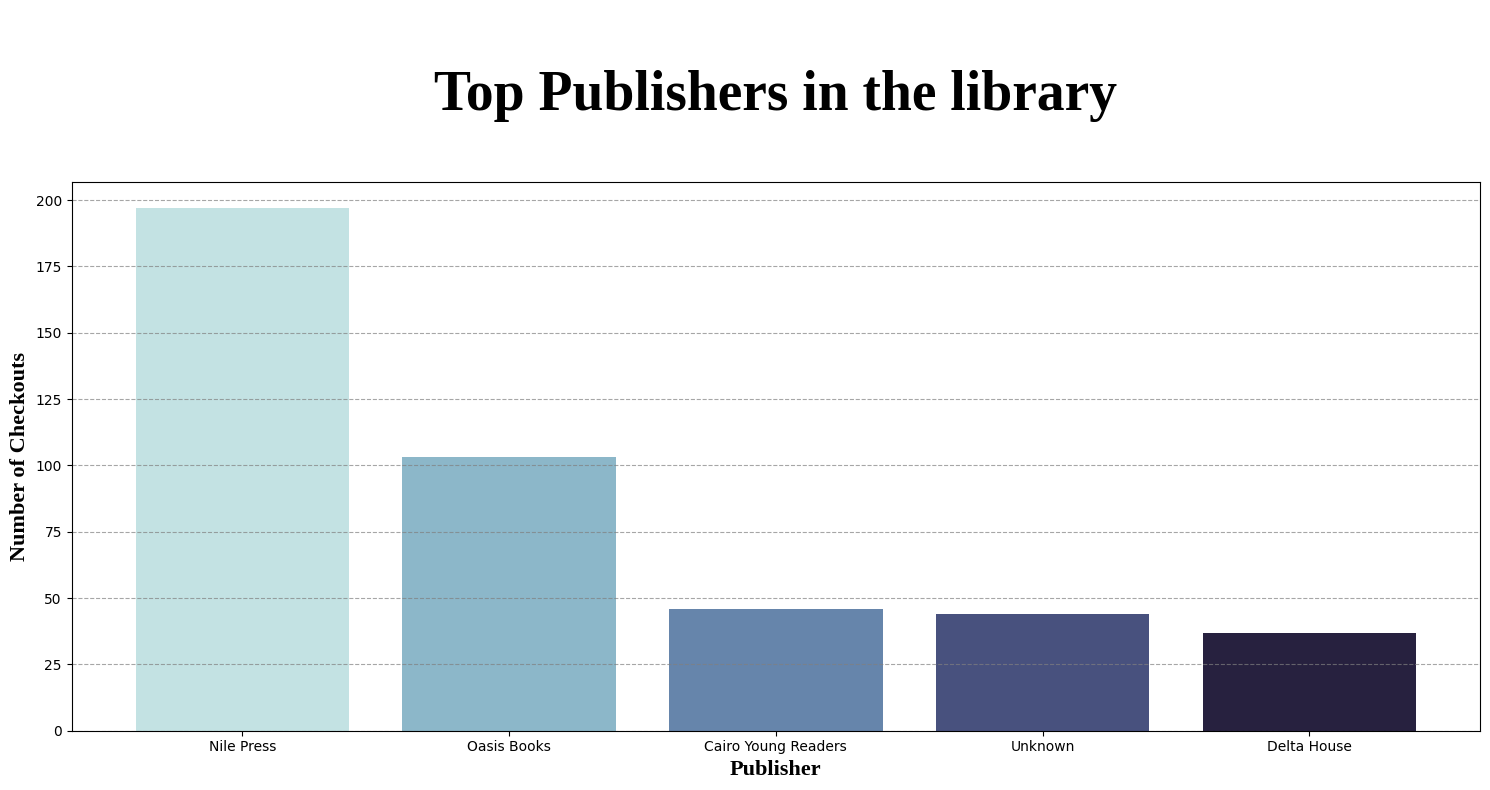

In [1436]:
# Question 1 : Which publishers have the most books checked out?

# To find which publishers have the most books checked out,
# we simply count the occurrences of each publisher in the 'publisher' column.
print("The 1st Visualization........")
print()
the_top_publishers = df_clean["publisher"].value_counts()

print(f"The top publishers by number of checkouts are : \n {the_top_publishers}")

# the visualization
#plotting
#x-axis
values = the_top_publishers.values # the values of the_top_publishers variable
# y-axis
labels = the_top_publishers.index
fig , axes = plt.subplots(figsize = (15,8))
# Get colors from 'flare' palette. The number of colors should match the number of publishers.
seaborn1_palette = sns.cubehelix_palette(n_colors=len(the_top_publishers), start=.2,rot=-.3) # the color palette used for the barchart
axes.bar(the_top_publishers.index , the_top_publishers.values , color = seaborn1_palette ) # creating the barchart
axes.set_title("\nTop Publishers in the library\n" , fontsize = 40 , fontweight = "bold" , fontfamily = "Liberation Serif")# the title of the plot
axes.set_ylabel("Number of Checkouts" , fontsize = 16, fontweight = "bold" , fontfamily = "Liberation Serif") # the label of the x-axis
axes.set_xlabel("Publisher" , fontsize = 16, fontweight = "bold" , fontfamily = "Liberation Serif")# the label of the y-axis
axes.grid(True , linestyle = "--" , alpha = 0.7 , color = "grey")# the grid
plt.gca().xaxis.grid(False) # Remove vertical gridlines of the grid for a cleaner look
plt.tight_layout() # to prevent any word getting on the other
plt.show() # showing the graph

Question 2: What book genres had the highest circulation?

The 2nd Visualization.............

The top book genres in the library : 
 genre
Adventure          130
Science            110
Friendship          61
Mystery             44
Historical          32
Nature              23
Science Fiction     21
Poetry               6
Name: count, dtype: int64


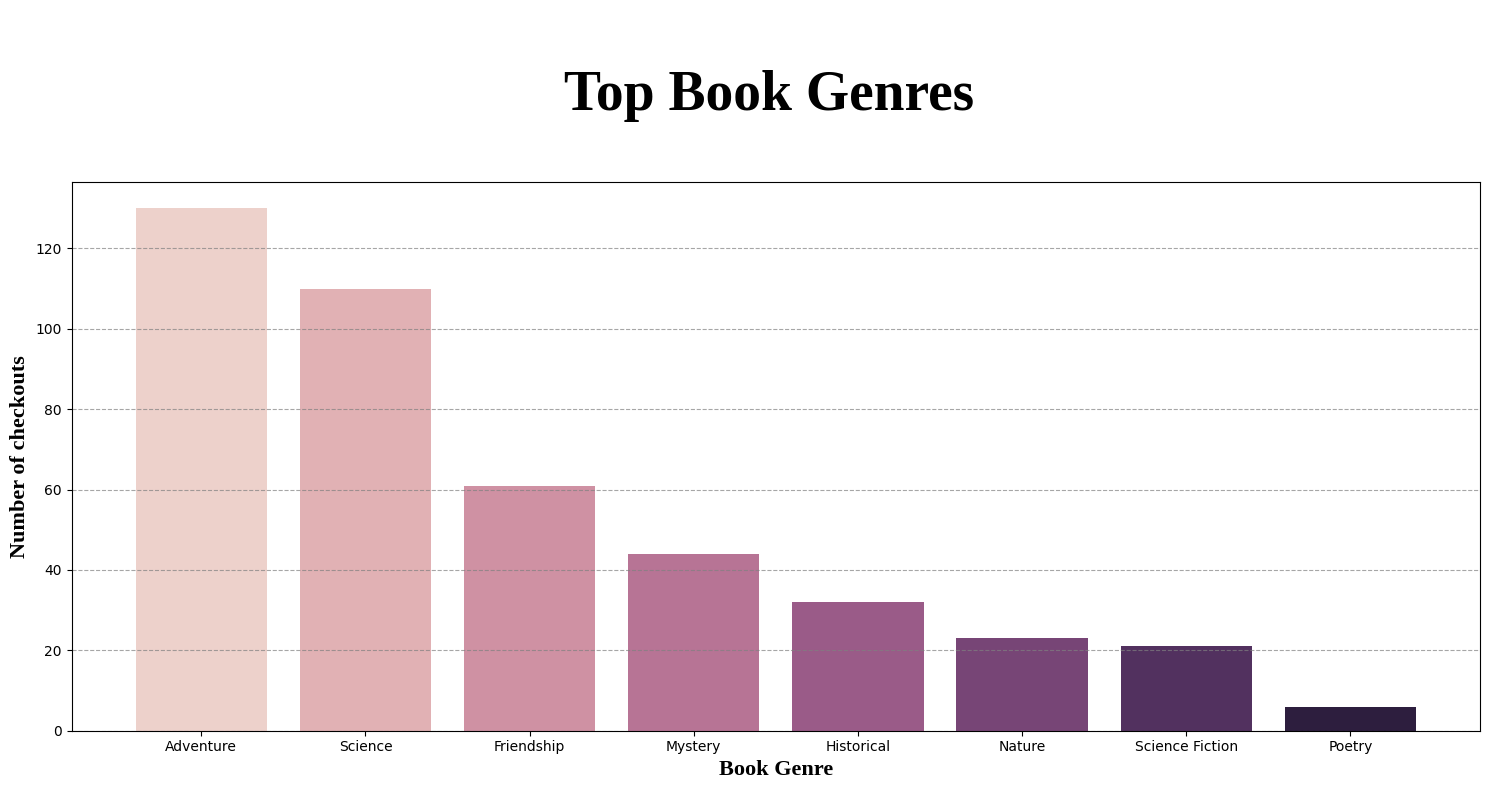

In [1437]:
# Question 2: What book genres had the highest circulation?
print("The 2nd Visualization.............")
print()
#getting the top book genres
the_top_genres = df_clean["genre"].value_counts()
print(f"The top book genres in the library : \n {the_top_genres}")

# the visualization
#plotting
fig , axes = plt.subplots(figsize = (15,8)) # creating the background
seaborn2_palette = sns.cubehelix_palette(n_colors=len(the_top_genres)) # the color palette
axes.bar(the_top_genres.index , the_top_genres.values , color = seaborn2_palette )# the line that creates the barchart
axes.set_title("\nTop Book Genres \n" , fontsize = 40 , fontweight = "bold" , fontfamily = "Liberation Serif")# the title of the barchart
axes.set_ylabel("Number of checkouts" , fontsize = 16, fontweight = "bold" , fontfamily = "Liberation Serif")# the y-axis label
axes.set_xlabel("Book Genre" , fontsize = 16, fontweight = "bold" , fontfamily = "Liberation Serif")# the x-axis label
axes.grid(True , linestyle = "--" , alpha = 0.7 , color = "grey") # the grid of the chart
plt.gca().xaxis.grid(False) # Remove vertical gridlines for a cleaner look
plt.tight_layout()
plt.show()

Question 3: What is the distribution of the various membership statuses amongst the borrowers?

The 3rd Visualization............

The distribution of the various membership statuses amongst the borrowers : 
 membership_status
Active      345
Inactive     82
Name: count, dtype: int64


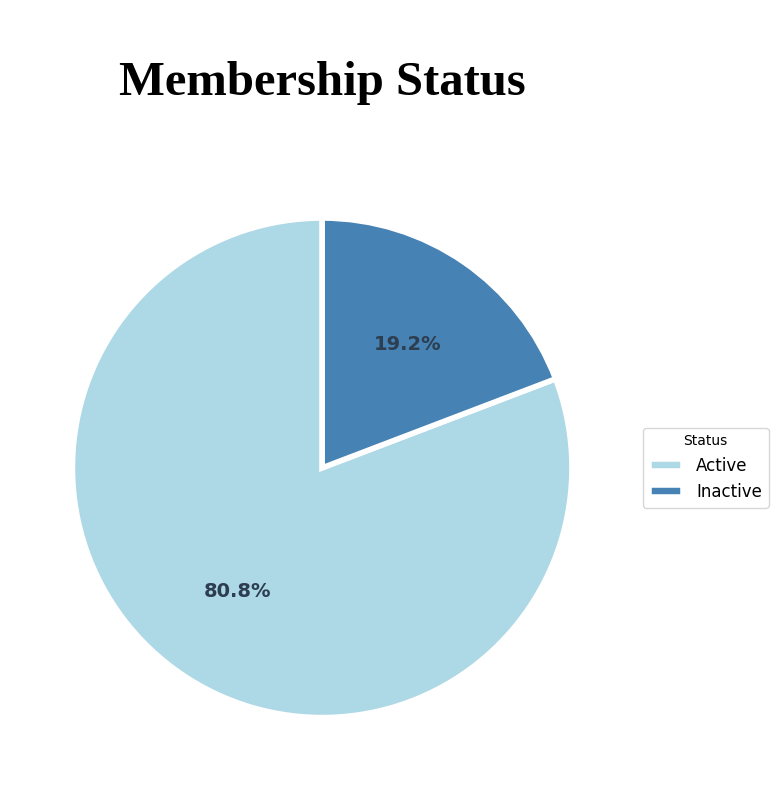

In [1438]:
# Question 3: What is the distribution of the various membership statuses amongst the borrowers?
print("The 3rd Visualization............")
print()
# getting the membership statuses of the members
the_top_membership_statuses = df_clean["membership_status"].value_counts()
print(f"The distribution of the various membership statuses amongst the borrowers : \n {the_top_membership_statuses}")

# the visualization
# the colors used for the pie chart
comparing_colors = ["lightblue" , "steelblue"]
#plotting
fig, axes = plt.subplots(figsize=(10, 8))# creating the figure and the axes
# creating the pie chart
# wedges: A list of the wedge objects (the actual colorful slices).
# texts: A list of label text objects (outside the slices).
# autotexts: A list of numerical value text objects (inside the slices).
wedges, texts, autotexts = axes.pie(
    the_top_membership_statuses.values,
    labels=None,            # Removed direct text labels for a cleaner look and putting it in the legend
    colors=comparing_colors,  # the palette of colors
    autopct='%1.1f%%',        # the figure and shape of the percentage on the pie chart
    startangle=90,                           # Keeps a clean, upright orientation
    wedgeprops={'edgecolor': 'white', 'linewidth': 4}  # Adds crisp white borders between slices for a profesional look
)

# Styling the percentage text inside the chart
for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')
    autotext.set_color('#2c3e50')           # Dark grey color for high contrast and readability

# Restoring your original big title
axes.set_title("\nMembership Status\n", fontsize=35, fontweight="bold", fontfamily="Liberation Serif")

# Adding a clean legend box on the side
axes.legend(
    wedges,
    the_top_membership_statuses.index,
    title="Status",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),    # Perfectly places the legend outside the chart boundaries
    fontsize=12
)

plt.tight_layout() # to get a tight layout
plt.show() # showing the chart

Question 4 : What are the busiest periods for checkouts?

The 4th Visualization..........

0      2024-10
1      2024-02
2      2024-06
3      2025-07
4      2024-06
        ...   
430    2025-07
431    2025-07
432    2025-07
433    2025-07
434    2025-07
Name: year_month, Length: 427, dtype: period[M]
year_month        2025-07-01 00:00:00
checkout_count                     64
Name: 18, dtype: object


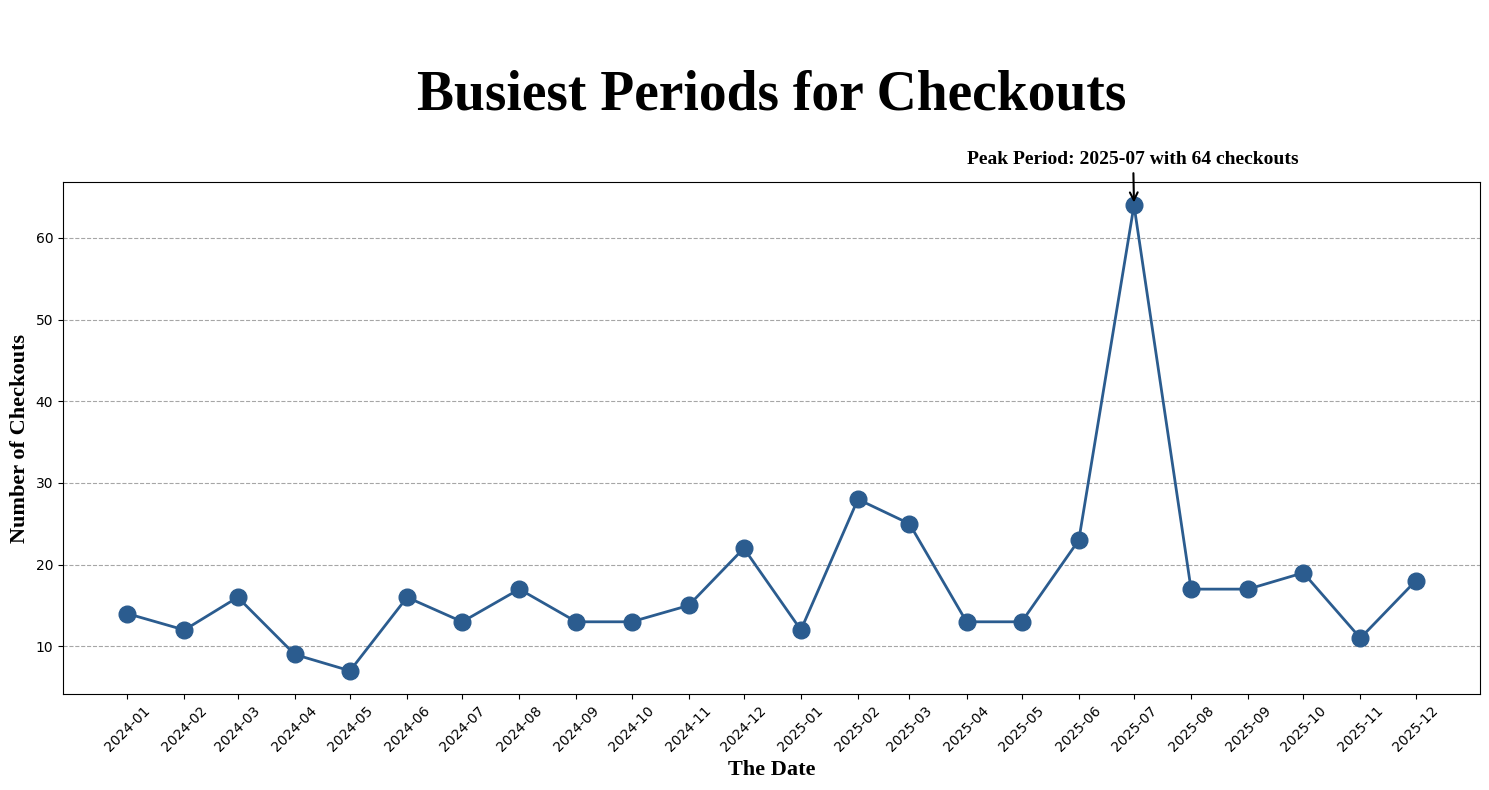

In [1439]:
# Question 4 : What are the busiest periods for checkouts
print("The 4th Visualization..........")
print()
# Ensure 'checkout_date' is in datetime format
df_clean["checkout_date"] = pd.to_datetime(df_clean["checkout_date"], format="mixed") # to accept any format for the date

#to prevent any modifications on the original cleaned dataset
df_for_time = df_clean.copy()

# Extract year and month
df_for_time["year_month"] = df_for_time["checkout_date"].dt.to_period("M") # Extracts the year and month from the dates and converts them into monthly periods without the days
print(df_for_time["year_month"])
# groups the data by the year_month column, counts the checkouts in each group, and saves it as a clean summary table named month_year.
month_year = df_for_time.groupby("year_month").size().reset_index(name = "checkout_count")
# reset_index() restores clean, sequential row numbering after operations like filtering or grouping, preventing errors during future data analysis.

# Convert 'year_month' back to a datetime object for plotting (the chart)
month_year["year_month"] = month_year["year_month"].dt.to_timestamp()
#Converts the monthly periods back into standard pandas timestamp objects, which makes them much easier for plotting libraries to handle on a chart.

# the visualization
# the peak month
peak = month_year.loc[month_year["checkout_count"].idxmax()]
print(peak)
#plotting
fig , axes = plt.subplots(figsize = (15,8)) # the figure and the axes
# creating the linechart
axes.plot(month_year["year_month"] , month_year["checkout_count"] , color = "#2b5c8f" , marker = "o" , markersize = 12 , linewidth = 2)
# setting the title
axes.set_title("\nBusiest Periods for Checkouts\n" , fontsize = 40 , fontweight = "bold" , fontfamily = "Liberation Serif")
# setting the y-axis label
axes.set_ylabel("Number of Checkouts" , fontsize = 16, fontweight = "bold" , fontfamily = "Liberation Serif")
# setting the x-axis label
axes.set_xlabel("The Date" , fontsize = 16, fontweight = "bold" , fontfamily = "Liberation Serif")
# setting the grid of the chart
axes.grid(True , linestyle = "--" , alpha = 0.7 , color = "grey")
# xticks
axes.set_xticks(ticks = month_year["year_month"])
axes.set_xticklabels(labels = month_year["year_month"].dt.strftime("%Y-%m"), rotation = 45)
plt.gca().xaxis.grid(False) # Remove vertical gridlines for a cleaner look
plt.tight_layout() # for a clean, nice chart without any element getting on the other
# the annotation
plt.annotate(
    f"Peak Period: {peak['year_month'].strftime('%Y-%m')} with {peak['checkout_count']} checkouts", # the text that will demonstrate the most important point on the line chart
    # .strftime('%Y-%m') turns the date needed to a month and a year date
    xy=(peak["year_month"],64), # the location of the arrow by the chart values
    xytext=(-120, 30), # the location of the text of the arrow by pixels
    textcoords="offset points",    # Enables relative pixel shifting instead of using chart values to ease the setting of the location
    arrowprops=dict(facecolor='black' , arrowstyle = "->" , lw=1.5), # the arrow
    fontsize=14, # the size of the writing
    fontweight="bold", # the length of the writing
    fontfamily="Liberation Serif" # the style of the writing
)
plt.show()

Question 5: Which neighborhoods have the most active members (highest average checkouts per member)?

The 5th Visualization...........

neighborhood
Shubra        5.833333
Nasr City     5.100000
Heliopolis    4.944444
Zamalek       4.714286
Maadi         3.750000
Name: avg_checkouts_per_member, dtype: float64


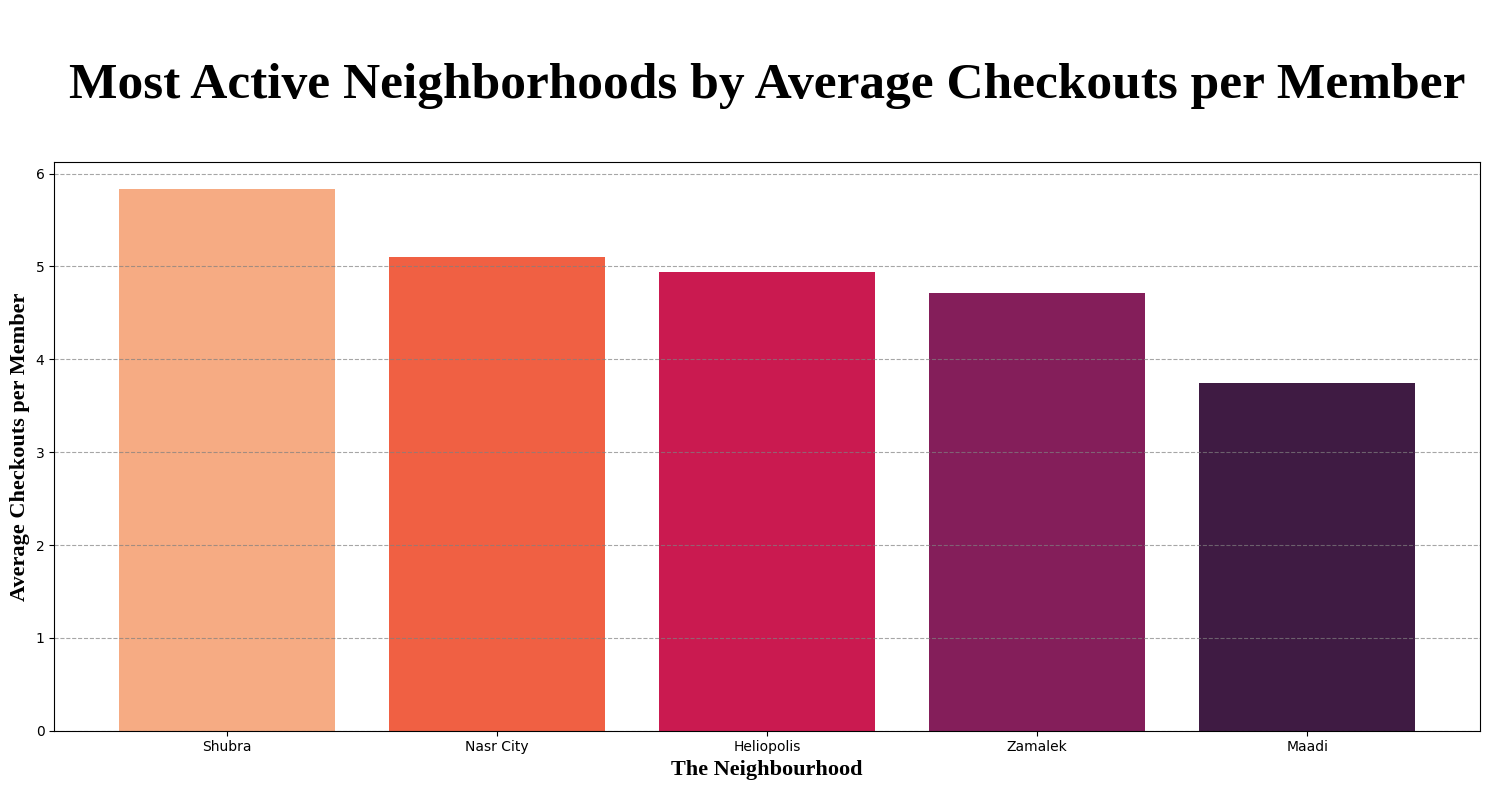

In [1440]:
# Question 5: Which neighborhoods have the most active members (highest average checkouts per member)?
print("The 5th Visualization...........")
print()
# making a copy of the dataset to prevent any editing on the original cleaned table
df_clean_copy = df_clean.copy()

# Cleaner, single groupby approach without many equations or math
# Calculate the average checkouts per member for each neighborhood
neighborhood_activity = df_clean_copy.groupby("neighborhood").agg(
    total_checkouts=('checkout_id', 'count'),
    unique_members=('member_id', 'nunique')
)

# Calculate the average and sort from highest to lowest
neighborhood_activity['avg_checkouts_per_member'] = (
    neighborhood_activity['total_checkouts'] / neighborhood_activity['unique_members']
)
# Sort to immediately see the "most active" neighborhoods at the top (Descending Order)
# Sort the main DataFrame first to keep underlying data aligned, preventing series decoupling warnings.
neighborhood_activity = neighborhood_activity.sort_values(by='avg_checkouts_per_member', ascending=False)
most_active_neighbors = neighborhood_activity['avg_checkouts_per_member']

print(most_active_neighbors)

# the visualization
#plotting
# creating the barchart
fig , axes = plt.subplots(figsize = (15,8)) # creating  the figure and the axes of the chart
seaborn3_palette = sns.color_palette("rocket_r" , n_colors = len(most_active_neighbors))# the palette of the barchart
# Cast the index explicitly to strings to prevent Matplotlib tracking errors with object/categorical data types.
axes.bar(most_active_neighbors.index.astype(str) , most_active_neighbors.values , color = seaborn3_palette ) # the barchart
# setting the title
axes.set_title("\nMost Active Neighborhoods by Average Checkouts per Member\n" , fontsize = 37 , fontweight = "bold" , fontfamily = "Liberation Serif")
# setting the y-axis label
axes.set_ylabel("Average Checkouts per Member" , fontsize = 16, fontweight = "bold" , fontfamily = "Liberation Serif")
# setting the x-axis
axes.set_xlabel("The Neighbourhood" , fontsize = 16, fontweight = "bold" , fontfamily = "Liberation Serif")
axes.grid(True , linestyle = "--" , alpha = 0.7 , color = "grey")# setting the grid of the chart
axes.xaxis.grid(False) # Remove vertical gridlines for a cleaner look
plt.tight_layout()
plt.show()


# **Getting the insights :**

In [1441]:
print("Getting the insights from the visiualizations.........")
time.sleep(1)
print("The process was completed successfully :)")

Getting the insights from the visiualizations.........
The process was completed successfully :)


# **The 1st Insight :**
### **- The Observation :**
The 1st chart shows the Top publishers in the library which clearly indicates that `Nile Press` is the dominant publisher which significantly has the most checkouts compared to the other publishers.

### **- The Magnitude :**
`Nile Press` got the most checkouts recorded as 197 , followed by `Oasis Books` with 103 checkouts.

### **- The Implication :**
This suggests that these 2 publishers are the major contributors to the library's collection and circulation.

### **- The Hypothesis :**
Can acquiring more books from `Nile Press` and `Oasis Books` further boost overall library circulation?


# **The 2nd Insight :**

### **- The Observation :**
The 2nd chart shows the distribution of book genres , clearly indicating that `Adventure` and `science` books are the most popular genres , compared to the other genres.

### **- The Magnitude :**
The `Adventure` books have reached to 130 checkouts , followed by `Science` books with 110 checkouts , while the `Poetry` books has the fewest with only 6 checkouts.

### **- The Implication :**
This suggests that the library's collection strategy should prioritise more `Adventure` and `Science` books to meet the members' demand. It also highlights an opportunity to promote less popular genres like `Poetry` books to increase the circulation of the library. We can also conduct surveys for the students to ask them about their interests and which genre they prefer the most.

### **- The Hypothesis :**
Would boosting the availability and visibility of books in the `Adventure` and `Science` genres lead to an increase in the total number of books circulated, and could focused promotional efforts enhance engagement with the less popular genres?

# **The 3rd Insight :**

### **- The Observation :**
The 3rd Visualization displays the distribution of membership statuses among borrowers , showing a clear majority of active members.

### **- The Magnitude :**
80% of the members are `Active` , while 19% are `Inactive`and this means that 345 members are active and 82 members are inactive.

### **- The Implication :**
This strong majority of active members is positive for the library, indicating high engagement. However, the 19% inactive members present an opportunity for targeted re-engagement campaigns. The Library could explore why members become inactive and develop strategies to encourage their return, potentially through personalised recommendations or special offers.

### **- The Hypothesis :**
 Would a targeted re-engagement campaign aimed at inactive members—using personalized content and incentives—be capable of bringing a significant number of them back into an active status and at the same time increasing overall library usage?

# **The 4th Insight :**

### **- The Observation :**
The 4th Visualization illustrates the busiest periods for book checkouts and there is a noticable peak in July 2025.

### **- The Magnitude :**
The peak period for checkouts was in July 2025,with 64 checkouts , significantly higher than the other months, which generally hover (in between) between 7 and 28 checkouts.

### **- The Implication :**
The peak in July 2025 likely corresponds to the `Reading Kickoff` event which occurs every summer. In order to deal with this increase in activity, the library should make sure it has sufficient staffing, enhance the availability of books, and may want to hold special promotions or events at that time to take advantage of the greater interest and we must try to conduct surveys and ask the people for suggestions to enhance the library.

### **- The Hypothesis :**
1. Will the staffing and book stock planning, together with event arrangements that correspond to the July Reading Kickoff, help to maximise member engagement and satisfaction during this busy period?

2. Will conducting events and running campaigns during the peak season help increase the engagement of the members?

# **The 5th Insight :**

### **- The Observation :**
The 5th Visualization shows the most active neighbourhoods based on average per member. `Shubra` stands out as the most active neighbourhood.

### **- The Magnitude :**
`Shubra` has the highest average checkouts per member at 5.83 , followed by `Nasr City` at approximately 5.10 and `Maadi` has the lowest average at 3.75.

### **- The Implication :**
The fact that the people of Shubra are very involved with the library shows this. In order to further boost engagement, the library could arrange community events or extend its services to Shubra. For neighborhoods showing lower levels of activity, such as Maadi, the library might look into outreach initiatives, form local partnerships, or carry out surveys in order to identify the obstacles to participation and then create specific strategies to increase member involvement.

### **- The Hypothesis :**
Might it be possible to raise the average number of checkouts per member in less active areas (for example, Maadi) by setting up targeted outreach programmes and forming community partnerships, thus getting those areas' activity levels nearer to those of neighbourhoods such as Shubra?



> # **After getting the insights , let's get to task 3**

# **Task 3 : Data Fairness & Version Control**

> ### The task will depend on the `cleaned combined CSV file (the cleaned dataset)` and on the `neighborhood` column specifically.

 ### Start by comparing the neighborhoods the program serves against each other. For every neighborhood present in the data, you need two numbers: how many members it has, and how many checkouts belong to it.

 ### The point of gathering both numbers isn't to describe each neighborhood on its own — it's to place them side by side so they can be measured against one another. A number only becomes meaningful once you can see how it compares.

In [1442]:
# imported the cleaned CSV file
print("Getting the Cleaned dataset.......")
cleaned_df_fairness = pd.read_csv("/content/31109170100123_Library_task2_cleaned_data.csv")# reading the csv file and getting the data from it
time.sleep(1) # sleep for 1 second
print("The process was completed successfully :)") # success message


Getting the Cleaned dataset.......
The process was completed successfully :)


In [1443]:
# comparing the neighborhoods the program serves against each other according to 2 numbers : how many members it has, and how many checkuts bolong to

print("Comparing betwee the neighbourhoods............")
time.sleep(2) # sleep for 1 second
# grouing and aggregation
neighborhood_comparing_members_checkouts = cleaned_df_fairness.groupby("neighborhood").agg(
    total_members=("member_id", "nunique"),
    total_checkouts=("checkout_id", "count")
)

# sorting the table in descending order accrding to the total_checkouts
neighborhood_comparing_members_checkouts = neighborhood_comparing_members_checkouts.sort_values(by="total_checkouts", ascending=False)

print("The process was completed successfully :)") # success message
print()
# printing the result
print("The result of the comparison :")
print(neighborhood_comparing_members_checkouts)

Comparing betwee the neighbourhoods............
The process was completed successfully :)

The result of the comparison :
              total_members  total_checkouts
neighborhood                                
Maadi                    36              135
Nasr City                20              102
Heliopolis               18               89
Zamalek                  14               66
Shubra                    6               35


### Visualization of Neighborhood Comparison

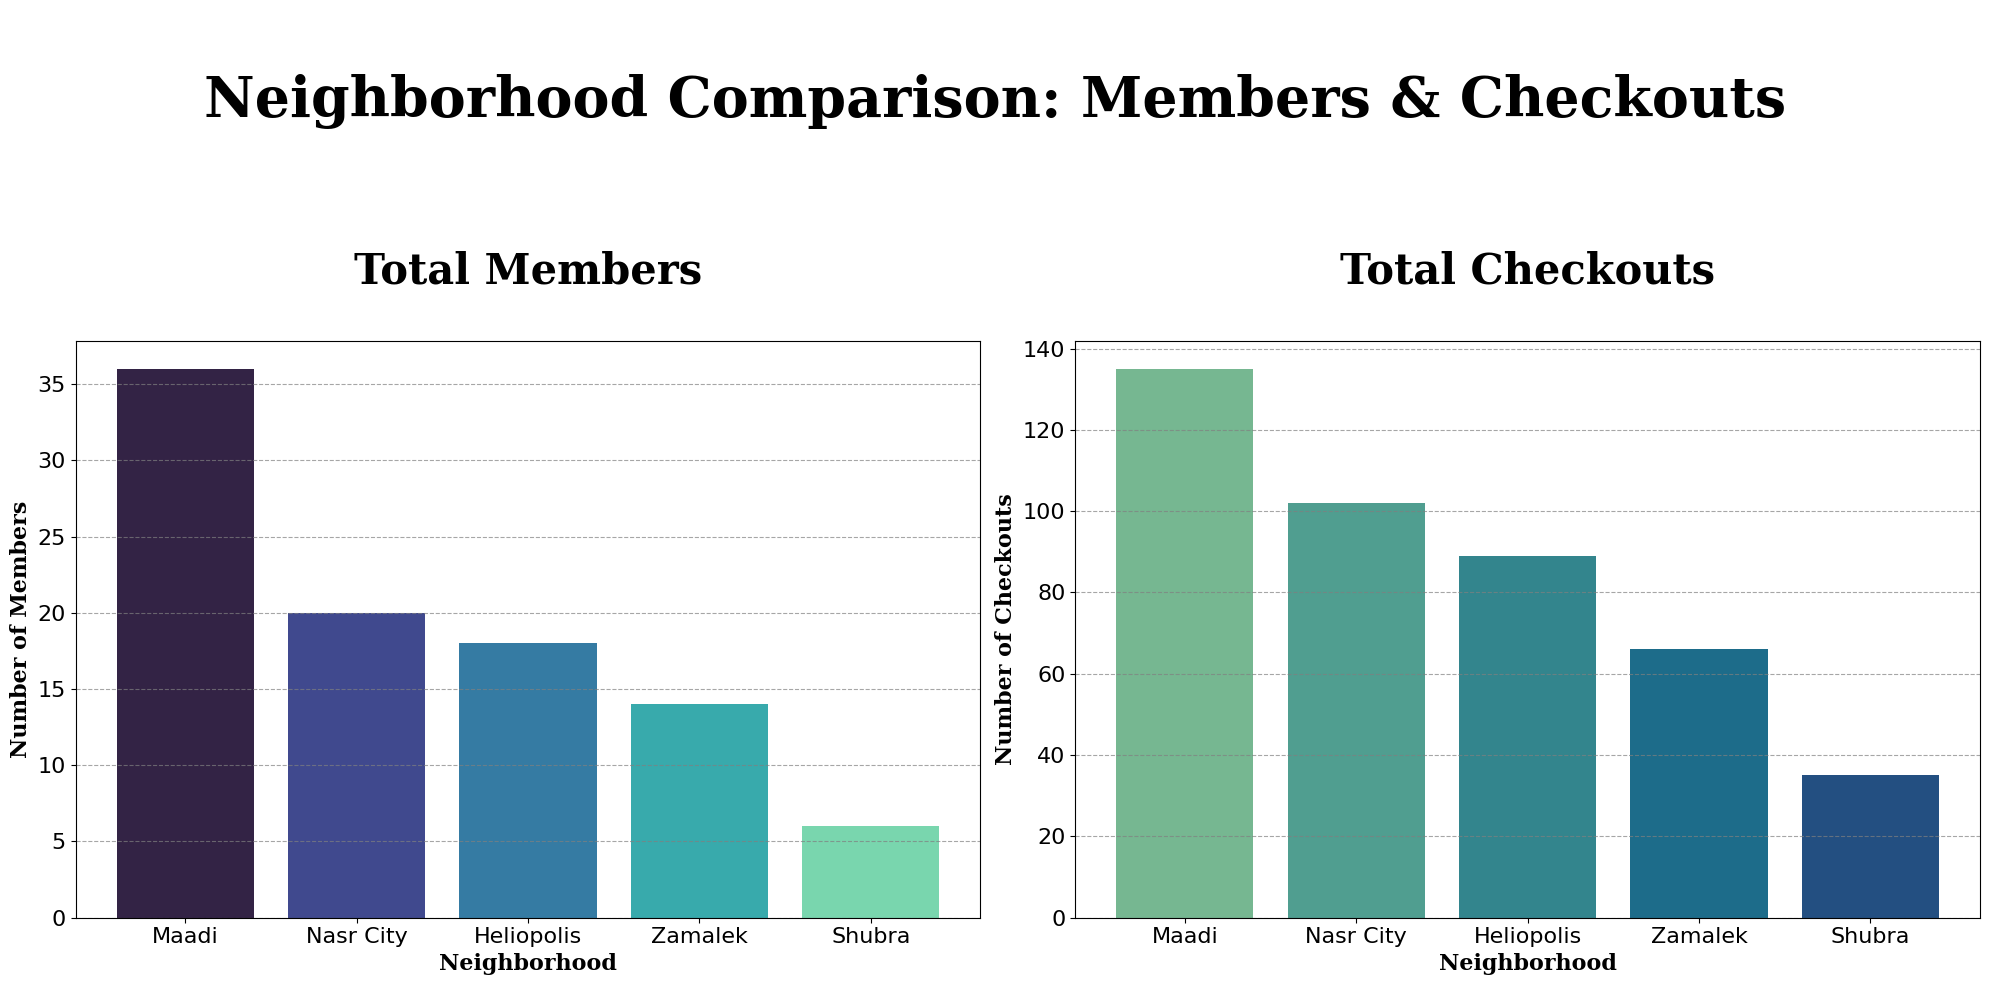

In [1444]:
# visualizing the comparision between the neighbourhoods
# creating 2 subplots
fig , axes = plt.subplots(nrows = 1 , ncols = 2 , figsize = (20 , 10))
# the used seaborn palettes
comarision_seaborn_palette1 = sns.color_palette("mako", n_colors = len(neighborhood_comparing_members_checkouts))
comarision_seaborn_palette2 = sns.color_palette("crest" , n_colors = len(neighborhood_comparing_members_checkouts))

# the 1st chart
axes[0].bar(neighborhood_comparing_members_checkouts.index ,
            neighborhood_comparing_members_checkouts["total_members"] ,
            color = comarision_seaborn_palette1)
axes[0].set_title("\nTotal Members\n" , fontfamily = "serif" , fontweight = "bold" , fontsize = 30) # the title
axes[0].set_ylabel("Number of Members" , fontsize = 16, fontweight = "bold" , fontfamily = "serif") # the y-label
axes[0].set_xlabel("Neighborhood" ,  fontsize = 16, fontweight = "bold" , fontfamily = "serif") # the x-label
axes[0].tick_params(axis='y', labelsize=16)# y-axis control
axes[0].tick_params(axis='x', labelsize=16, labelrotation=0, labelbottom=True) # x-axis control
axes[0].grid(True , linestyle = "--" , alpha = 0.7 , color = "grey")# the grid
axes[0].xaxis.grid(False) # Remove vertical gridlines for a cleaner look


# the 2nd chart
axes[1].bar(neighborhood_comparing_members_checkouts.index ,
            neighborhood_comparing_members_checkouts["total_checkouts"] ,
            color = comarision_seaborn_palette2)
axes[1].set_title("\nTotal Checkouts\n" ,fontfamily = "serif" , fontweight = "bold" , fontsize = 30)# the title
axes[1].set_ylabel("Number of Checkouts" , fontsize = 16, fontweight = "bold" , fontfamily = "serif") # the y-label
axes[1].set_xlabel("Neighborhood" ,  fontsize = 16, fontweight = "bold" , fontfamily = "serif") # the x-label
axes[1].tick_params(axis='y', labelsize=16)# y-axis control
axes[1].tick_params(axis='x', labelsize=16, labelrotation=0, labelbottom=True) #  x-axis control
axes[1].grid(True , linestyle = "--" , alpha = 0.7 , color = "grey") # the grids
axes[1].xaxis.grid(False) # Remove vertical gridlines for cleaner look

# the main heading (title) for the figure not thye two axes
fig.suptitle("\nNeighborhood Comparison: Members & Checkouts\n", fontsize=40, fontweight="bold", fontfamily="serif")

plt.tight_layout()
plt.show()

In [1445]:
time.sleep(1)
print("Thank you for exploring the library system. Please let me know if you have any questions or feedback. :) ")

Thank you for exploring the library system. Please let me know if you have any questions or feedback. :) 
